# TEnKF Lorenz-96

This notebook reproduces the reference experiment using the following configuration:

| Parameter | Value |
|-----------|-------|
| σ_obs     | 5     |
| N_ens     | 20    |
| Obs density | 1.0 (all 40 grid points) |
| α (tempering scale) | 2 |
| N_temp    | 2     |

**Before running this notebook:**
1. Compile the Fortran modules: `bash compile.sh`
2. Generate the nature run: `python run_nature.py`
3. Run the assimilation sweep: `python run_example.py`

The cells below load the output and reproduce the key diagnostics.

## Nature and Operator

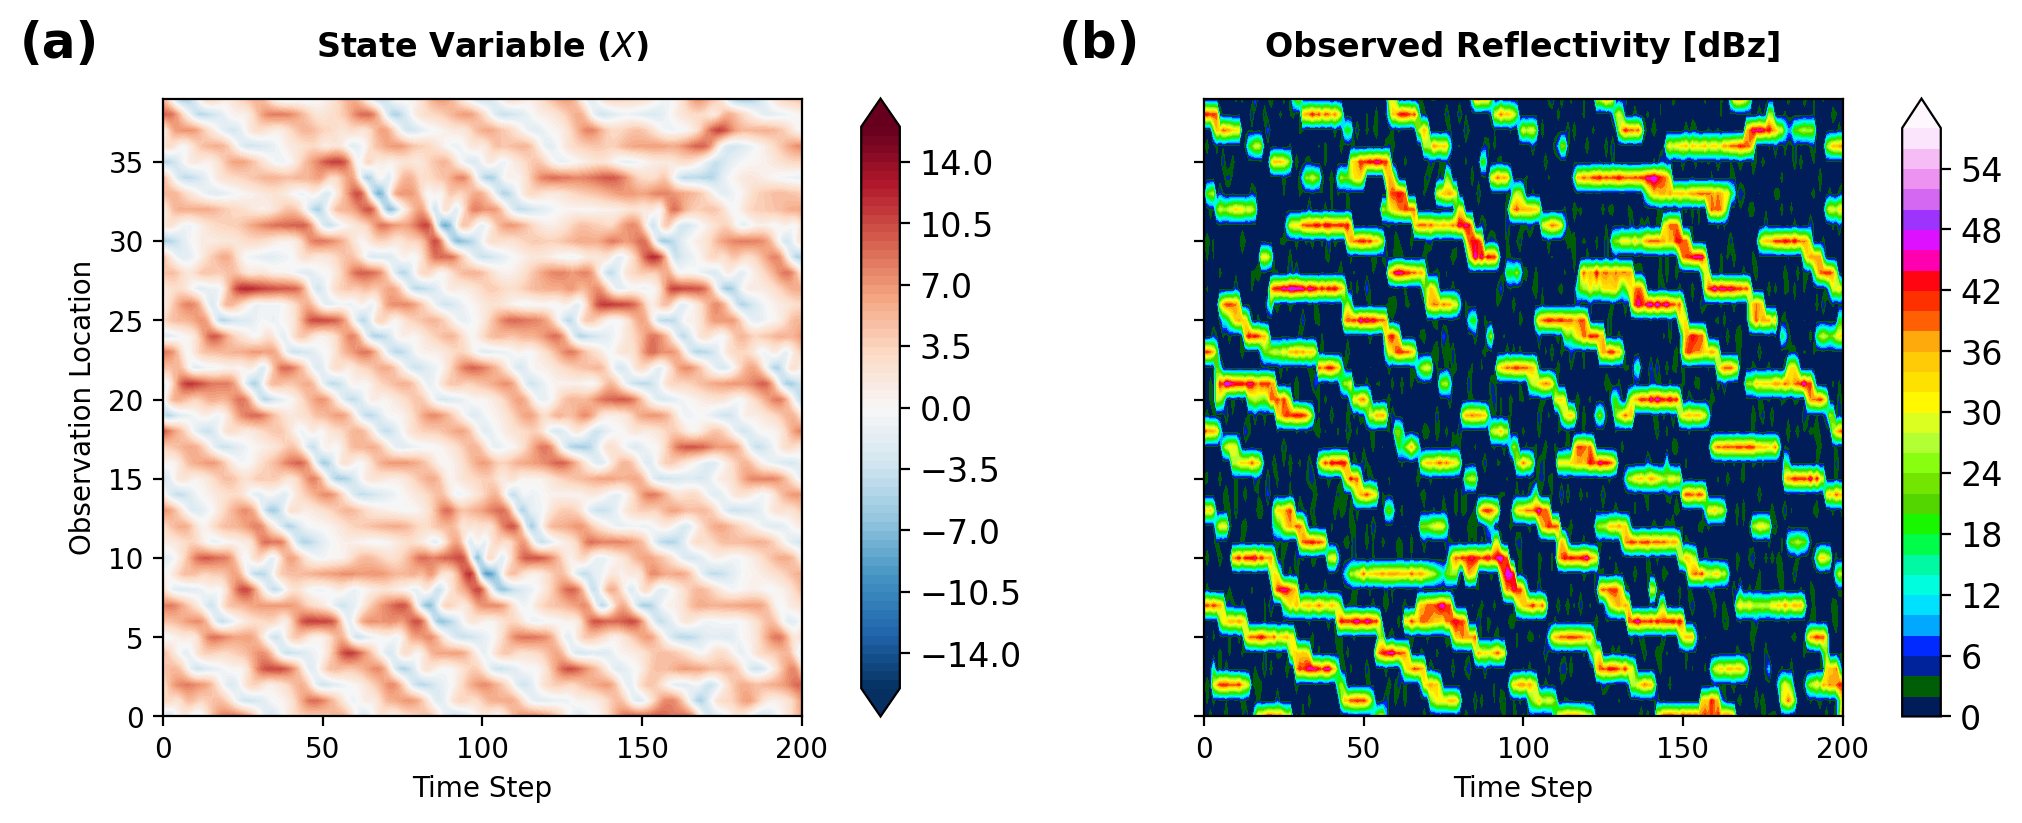

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

ROOT      = os.path.abspath('')   # repo root (assumes notebook run from repo root)
nature_FILE  = os.path.join(ROOT, 'data', 'Nature',
                         'Paper_Nature_Freq4_Den1.0_Type3_ObsErr5.npz')
assert os.path.exists(nature_FILE), (
    f'Output file not found: {nature_FILE}\n'
    'Run  python run_nature.py  first.'
)

data = np.load(nature_FILE, allow_pickle=True)

ObsConf=data['ObsConf']
XNature=data['XNature']
YObs=data['YObs']
ObsLoc=data['ObsLoc']
NPlot=201

# --- Process Data ---
tmpnobs = XNature.shape[0]
tmpntimes = XNature.shape[2]

# Reshape observations to (Location, Time)
tmpobs = np.reshape(YObs[:, 0], [tmpntimes, tmpnobs]).transpose()

# Slice the last NPlot steps
plot_data_x = XNature[:, 0, -NPlot:]
plot_data_y = tmpobs[:, -NPlot:]

# Define Levels
clevs1 = np.arange(-16, 16.5, 0.5) # State variable levels
clevs2 = np.arange(0.0, 60.0, 2)   # Reflectivity levels (step 2 is cleaner than 1)

# --- Plotting ---

fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True, dpi=200, constrained_layout=True)

# Panel (a): State Variable X
cf1 = axs[0].contourf(plot_data_x, clevs1, cmap='RdBu_r', extend='both')
axs[0].set_ylabel('Observation Location')
axs[0].set_xlabel('Time Step')
axs[0].set_title('State Variable ($X$)', fontweight='bold', pad=15)

cbar1 = fig.colorbar(cf1, ax=axs[0], location='right', aspect=40, pad=0.02)
cbar1.ax.tick_params(labelsize=12)

# Panel (b): Reflectivity
cf2 = axs[1].contourf(plot_data_y, clevs2, cmap='gist_ncar', extend='max')
axs[1].set_xlabel('Time Step')
axs[1].set_title('Observed Reflectivity [dBz]', fontweight='bold', pad=15)
cbar2 = fig.colorbar(cf2, ax=axs[1], location='right', aspect=40, pad=0.02)
cbar2.ax.tick_params(labelsize=12)

letters = ['(a)', '(b)']
for ax, letter in zip(axs, letters):
    ax.text(-0.1, 1.05, letter, transform=ax.transAxes, 
            fontsize=18, fontweight='bold', va='bottom', ha='right')

plt.show()


## Analysis

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
# Paths
ROOT      = os.path.abspath('')   # repo root (assumes notebook run from repo root)
OUT_FILE  = os.path.join(ROOT, 'data', 'output',
                         'example_LETKF_ObsErr5_Nens20_NTemp2_alpha2.npz')

assert os.path.exists(OUT_FILE), (
    f'Output file not found: {OUT_FILE}\n'
    'Run  python run_example.py  first.'
)

data = np.load(OUT_FILE, allow_pickle=True)
print('Keys:', list(data.keys()))
print('Inflation range  :', data['mult_inf_range'])
print('Localization range:', data['loc_scale_range'])

Keys: ['NormalEnd', 'mult_inf_range', 'loc_scale_range', 'total_analysis_rmse', 'total_forecast_rmse', 'total_analysis_sprd', 'total_forecast_sprd', 'obs_err_label', 'n_ens', 'obs_density', 'alpha_scale', 'n_temp']
Inflation range  : [1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4  1.45 1.5  1.55 1.6 ]
Localization range: [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5]


## Analysis RMSE — (inflation × localization) heatmap

Each cell shows the time-mean analysis RMSE for a given
(multiplicative inflation, localization half-width) pair.
The optimal configuration is marked with a star.

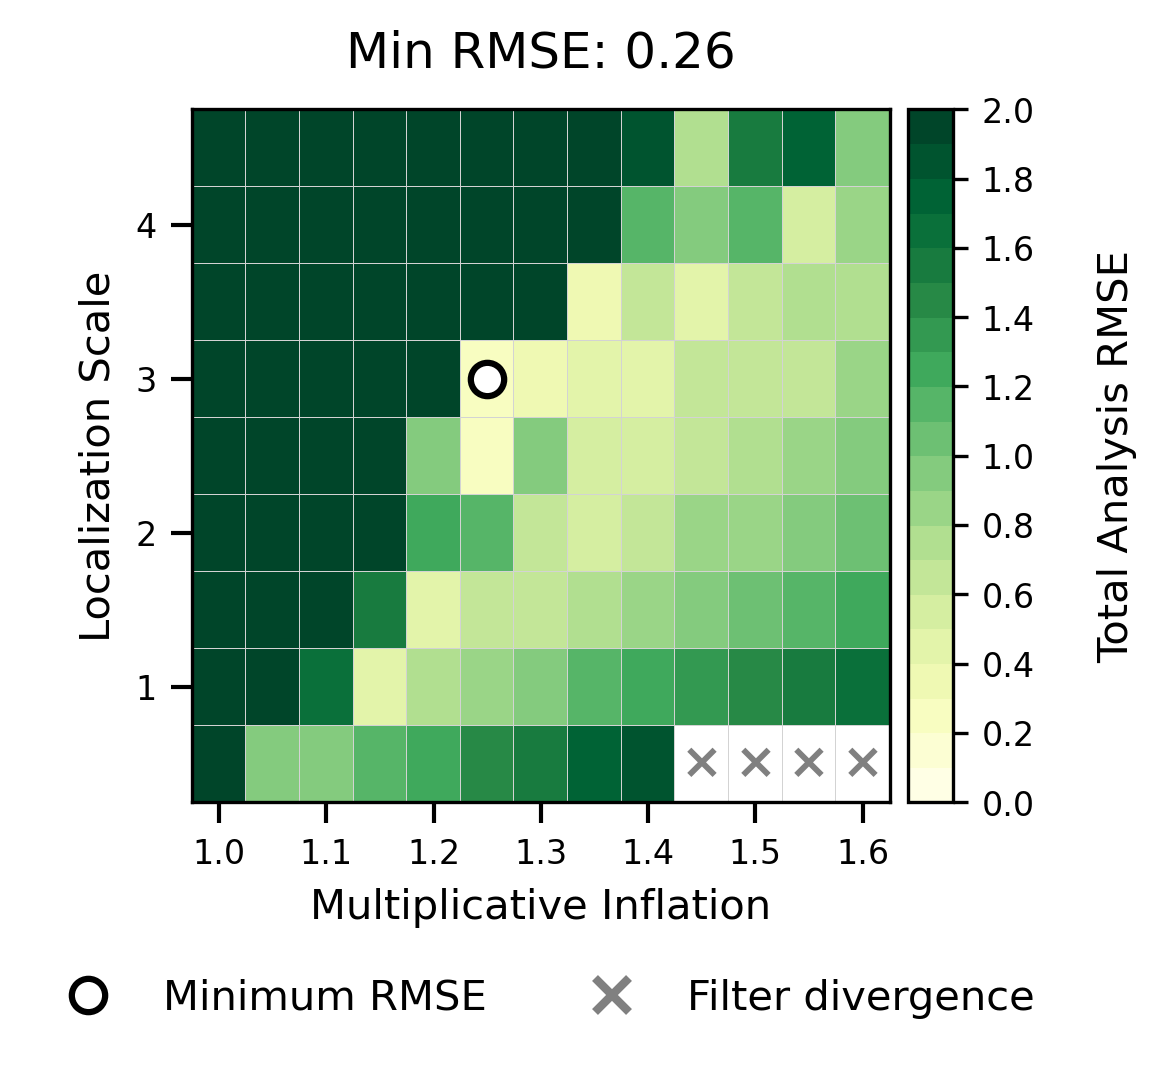

In [40]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)

cbar_ax = fig.add_axes([0.92, 0.11, 0.05, 0.77])  # x, y, width, height

vmin, vmax = 0, 2
panel_label_counter = 0

mult_inf_range = data.get('mult_inf_range', np.arange(1.0, 1.6, 0.05))
loc_scale_range = data.get('loc_scale_range', np.arange(0.5, 5.0, 0.5))

total_analysis_rmse = data['total_analysis_rmse']

# Mask out non-convergent cases (where NormalEnd is False)
NormalEnd = (1 - data['NormalEnd']).astype(bool)
total_analysis_rmse[NormalEnd] = np.nan


min_rmse = np.nanmin(total_analysis_rmse)
idx_min = np.where(total_analysis_rmse == min_rmse)
best_mult_inf = mult_inf_range[idx_min[0][0]]
best_loc_scale = loc_scale_range[idx_min[1][0]]


levels = np.arange(vmin, vmax + 0.1, 0.1)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)

im = ax.pcolormesh(mult_inf_range, loc_scale_range, total_analysis_rmse.T,
                cmap='YlGn', norm=norm, edgecolors='lightgray', linewidth=0.001,shading='nearest')            
ax.plot(best_mult_inf, best_loc_scale, 'w.', markersize=16, markeredgecolor='black',markeredgewidth=1.5)

nan_mask = np.isnan(total_analysis_rmse.T)
for (y, x), is_nan in np.ndenumerate(nan_mask):
    if is_nan:
        xi = mult_inf_range[x]
        yi = loc_scale_range[y]
        ax.text(xi, yi, '×', ha='center', va='center', color='gray', fontsize=12, fontweight='bold')

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.tick_params(which='major', length=5, width=1, labelsize=8)

ax.set_title(f"Min RMSE: {min_rmse:.2f}",pad=10)


ax.set_ylabel('Localization Scale')
ax.set_xlabel('Multiplicative Inflation')

    
cbar = fig.colorbar(im, cax=cbar_ax,ticks=np.arange(vmin, vmax + 0.2, 0.2))
cbar.set_label('Total Analysis RMSE', fontsize=10, labelpad=15)
cbar.ax.tick_params(labelsize=8)

white_dot = mlines.Line2D([], [], marker='.', color='none',
                           markerfacecolor='white', markeredgecolor='black',
                           markeredgewidth=1.5, markersize=16,
                           label='Minimum RMSE')
cross = mlines.Line2D([], [], marker='x', color='gray',
                       linestyle='none', markersize=8, markeredgewidth=2.0,
                       label='Filter divergence')

fig.legend(handles=[white_dot, cross],
           loc='upper center',
           bbox_to_anchor=(0.5, -0.2),
           bbox_transform=ax.transAxes,
           ncol=2, fontsize=10,
           frameon=False)
plt.show()